[Index](Index.ipynb) - [Prev](Qiskit_basics.ipynb) - [Next](Hadamard_gate.ipynb)

## Rotation gates <a id ='rotationgates'></a>

We will now play with other gates, the rotation gates. Rotation gates are parameterized gates, this means that the way they operate depends on a parameter (angle), which is given as an input. Parametrized gates are very useful because they allow us to manipulate the outcome of the circuit by tunning the parameters.

## RZ
Let us first try the Rz gate. This gate is also known as the $R_\phi$ gate (since it is the $\phi$ angle in Bloch sphere that changes) and it is a rotation around the Z-axis. 

Before running the code

> #### Question 1:
> What do you expect is the output of a measurment when rotating the qubit around the Z-axis?

In [2]:
# Quantum packages
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator

# Plotting packages
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes

State of qubit after execution of Rz = [6.123234e-17-1.j 0.000000e+00+0.j]


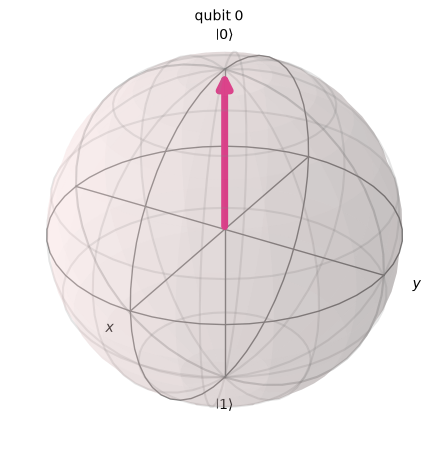

In [3]:
from math import pi
import numpy as np

# Rotation angle
angle = pi

# Define circuit
circuit = QuantumCircuit(1, 1)

# Define initial state |0>
initial_state = [1, 0]
circuit.initialize(initial_state, 0)

# Apply an Rz rotation of 180 degrees
circuit.rz(angle, 0)

# ---- Add extra gates to execute on qubit here----

# Obtain the resulting statevector
state = Statevector.from_instruction(circuit)

print("State of qubit after execution of Rz = " + str(state.data))

# Visualize circuit
circuit.draw(output='mpl')

# Visualize state in Bloch sphere
plot_bloch_multivector(state)

> #### Exercise 1:
> Comment the Rz gate and compare the result before the gate with the results after applying a gate.

> #### Question 2:
> What has changed in the qubit state? Does this influence the measurment?

> #### Exercise 2:
> Uncomment the measurment and run the code again. What do you get?

## Rx and Ry

Just as with the Rz, we can apply parameterized rotations in the Y and Z axis. 

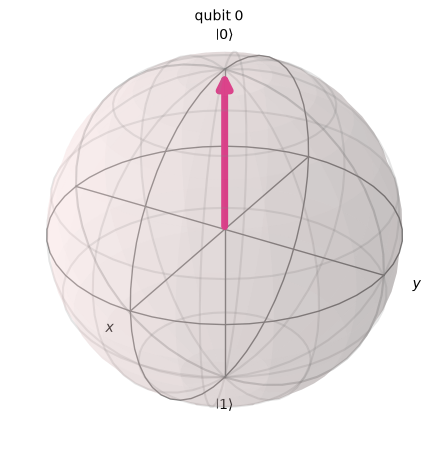

In [4]:
# visualize bloch sphere
plot_bloch_multivector(state)

> #### Question 3:
> What measurment outcome do you expect after rotating the qubit on the X-axis by $\pi/2$? What about rotating on the Y-axis?

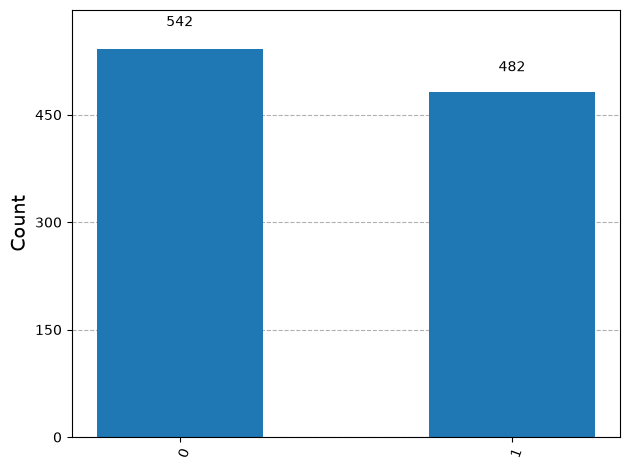

In [6]:
# Rotation angle
angle = pi / 2

# Define circuit
circuit = QuantumCircuit(1, 1)

# Define initial state |0>
initial_state = [1, 0]
circuit.initialize(initial_state, 0)

# Apply an Rx rotation of 90 degrees
circuit.rx(angle, 0)

# ---- Add extra gates to execute on qubit here----

# Add a measurement to the circuit
circuit.measure(0, 0)

# Run the circuit on the simulator
backend = AerSimulator()
compiled_circuit = transpile(circuit, backend)
result = backend.run(compiled_circuit).result()
counts = result.get_counts()

# Plot histogram
plot_histogram(counts)

> #### Question 4:
> What is the difference between applying an Rx or an Ry rotation? What changes in the qubit state? (hint: you might want to use the statevector_simulator backend to check this)

## S and T gates
Some rotations have their own name, for example:


- S-gate (sometimes known as the $\sqrt Z$), is a rotation around the Z-axis (R$_z$ or R-$\phi$) with $\phi=\pi/2$

- T-gate is a very commonly used gate, is also a Z-axis rotation but with $\phi=\pi/4$

> #### Question 3:
> What happens if you apply two consecutive S gates or two consecutive T gates?

Circuits that have gates that depend on an parameter, eg. the angle, are called parametrized circuits. Parametrized circuits can be used for example to find the optimal solution of a problem. This is normally done by using a hybrid workflow where the optimization is done classically but the output is computed in a quanutm computer. The two work in tandem to find the solution to a problem. Examples of these type of algorithms are  the variational quantum eigensolver (VQE) and the quanutm approximate optimization algorithm (QAOA) (you will see more about this later)